In [60]:
import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("Token loaded:", HF_TOKEN is not None)

con = duckdb.connect()

con.execute(
    "CREATE SECRET (TYPE huggingface, TOKEN ?)",
    [HF_TOKEN]
)

rel = "hf://datasets/FlyRank/internship-warehouse"

daily_path = f"{rel}/fact_content_daily_performance/**/*.parquet"

print("DuckDB + Hugging Face connection ready!")

Token loaded: True
DuckDB + Hugging Face connection ready!


# Google Search Ranking & Discoverability Capstone

## Refresh / Content Opportunity Scoring

### Research Question

Which content items should be prioritized for refresh review based on their search visibility, CTR, and freshness?

### Goal

Build a machine learning model that ranks content items by refresh-review priority.

This project provides a decision-support ranking and does not claim that refreshing content will cause better Google rankings or search performance.

In [61]:
march_check = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT content_hash_id) AS unique_content,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date
    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31'
""").df()

march_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_content,first_date,last_date
0,9841378,331437,2026-03-01,2026-03-31


In [62]:
april_check = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT content_hash_id) AS unique_content,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date
    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    WHERE report_date BETWEEN '2026-04-01' AND '2026-04-30'
""").df()

april_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_content,first_date,last_date
0,10424730,362172,2026-04-01,2026-04-30


In [63]:
overlap_check = con.sql(f"""
    WITH march AS (
        SELECT DISTINCT
            client_hash_id,
            content_hash_id
        FROM read_parquet(
            '{daily_path}',
            hive_partitioning=true
        )
        WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31'
    ),
    april AS (
        SELECT DISTINCT
            client_hash_id,
            content_hash_id
        FROM read_parquet(
            '{daily_path}',
            hive_partitioning=true
        )
        WHERE report_date BETWEEN '2026-04-01' AND '2026-04-30'
    )
    SELECT COUNT(*) AS overlapping_content
    FROM march
    INNER JOIN april
        USING (client_hash_id, content_hash_id)
""").df()

overlap_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,overlapping_content
0,331436


In [64]:
april_clicks = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS april_impressions,
        SUM(gsc_clicks) AS april_clicks
    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    WHERE report_date BETWEEN '2026-04-01' AND '2026-04-30'
      AND gsc_data_available IS TRUE
    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("April content rows:", len(april_clicks))
print()
print(april_clicks.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

April content rows: 194760

            client_hash_id           content_hash_id  april_impressions  \
0  client_62f4a7e64f5e0096  content_35d979572550dd7f             1180.0   
1  client_62f4a7e64f5e0096  content_d95e1739253d6a65              168.0   
2  client_62f4a7e64f5e0096  content_405cc2e0475690e9              249.0   
3  client_62f4a7e64f5e0096  content_fdb0d09a710f671c              336.0   
4  client_62f4a7e64f5e0096  content_a7b1f7921f001dce              832.0   

   april_clicks  
0           0.0  
1           0.0  
2           0.0  
3           0.0  
4           0.0  


In [65]:
march_performance = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS march_impressions,
        SUM(gsc_clicks) AS march_clicks
    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31'
      AND gsc_data_available IS TRUE
    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

capstone_base = march_performance.merge(
    april_clicks,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("March rows:", len(march_performance))
print("April rows:", len(april_clicks))
print("Overlapping rows:", len(capstone_base))

capstone_base.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March rows: 176738
April rows: 194760
Overlapping rows: 158549


,client_hash_id,content_hash_id,march_impressions,march_clicks,april_impressions,april_clicks
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,77.0,0.0,27.0,0.0
1,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,10849.0,22.0,16121.0,23.0
2,client_62f4a7e64f5e0096,content_e689bc511192751a,61.0,0.0,81.0,1.0
3,client_62f4a7e64f5e0096,content_7dbc094b799e05a4,705.0,1.0,213.0,0.0
4,client_62f4a7e64f5e0096,content_40b10da45f4c1cb5,50.0,0.0,23.0,0.0


In [66]:
capstone_base["march_ctr"] = (
    capstone_base["march_clicks"]
    / capstone_base["march_impressions"]
)

capstone_base["april_ctr"] = (
    capstone_base["april_clicks"]
    / capstone_base["april_impressions"]
)

# Keep only rows with measurable search exposure in both months
capstone_base = capstone_base[
    (capstone_base["march_impressions"] > 0) &
    (capstone_base["april_impressions"] > 0)
].copy()

capstone_base["ctr_change"] = (
    capstone_base["april_ctr"] - capstone_base["march_ctr"]
)

print("Rows with measurable exposure in both months:", len(capstone_base))
print()
print(capstone_base[
    ["march_ctr", "april_ctr", "ctr_change"]
].describe())

Rows with measurable exposure in both months: 158549

           march_ctr      april_ctr     ctr_change
count  158549.000000  158549.000000  158549.000000
mean        0.003719       0.003028      -0.000692
std         0.025448       0.025943       0.034965
min         0.000000       0.000000      -1.000000
25%         0.000000       0.000000      -0.000572
50%         0.000000       0.000000       0.000000
75%         0.002514       0.001791       0.000000
max         1.000000       1.000000       1.000000


In [67]:
import pandas as pd

ctr_change_summary = pd.Series({
    "CTR decreased": (capstone_base["ctr_change"] < 0).mean() * 100,
    "CTR unchanged": (capstone_base["ctr_change"] == 0).mean() * 100,
    "CTR increased": (capstone_base["ctr_change"] > 0).mean() * 100,
})

print("CTR change distribution:")
print(ctr_change_summary.round(2))

print("\nCTR change quantiles:")
print(
    capstone_base["ctr_change"]
    .quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

CTR change distribution:
CTR decreased    30.75
CTR unchanged    49.79
CTR increased    19.46
dtype: float64

CTR change quantiles:
0.01   -0.038462
0.05   -0.007042
0.10   -0.003387
0.25   -0.000572
0.50    0.000000
0.75    0.000000
0.90    0.001707
0.95    0.004405
0.99    0.024841
Name: ctr_change, dtype: float64


In [68]:
decline_threshold = capstone_base["ctr_change"].quantile(0.10)

capstone_base["refresh_opportunity"] = (
    capstone_base["ctr_change"] <= decline_threshold
).astype(int)

print("Decline threshold:", decline_threshold)
print()
print(
    capstone_base["refresh_opportunity"]
    .value_counts()
    .rename(index={0: "No opportunity", 1: "Refresh opportunity"})
)

print()
print(
    "Positive label rate:",
    round(capstone_base["refresh_opportunity"].mean() * 100, 2),
    "%"
)

Decline threshold: -0.0033870299136238755

refresh_opportunity
No opportunity         142694
Refresh opportunity     15855
Name: count, dtype: int64

Positive label rate: 10.0 %


In [69]:
label_summary = (
    capstone_base["refresh_opportunity"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "No opportunity",
        1: "Refresh opportunity"
    })
)

print("Label counts:")
print(label_summary)

print("\nLabel percentages:")
print(
    (label_summary / len(capstone_base) * 100).round(2)
)

Label counts:
refresh_opportunity
No opportunity         142694
Refresh opportunity     15855
Name: count, dtype: int64

Label percentages:
refresh_opportunity
No opportunity         90.0
Refresh opportunity    10.0
Name: count, dtype: float64


In [70]:
march_features = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS march_impressions,
        SUM(gsc_clicks) AS march_clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE 0
        END AS march_ctr,

        AVG(gsc_avg_position) AS march_avg_position,

        SUM(ga4_pageviews) AS march_pageviews,
        SUM(ga4_sessions) AS march_sessions

    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31'
      AND gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("March feature rows:", len(march_features))
print()
print("Features:")
print(march_features.columns.tolist())
print()
print(march_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March feature rows: 176738

Features:
['client_hash_id', 'content_hash_id', 'march_impressions', 'march_clicks', 'march_ctr', 'march_avg_position', 'march_pageviews', 'march_sessions']

            client_hash_id           content_hash_id  march_impressions  \
0  client_73cda7b4e4f265ea  content_b7e512995f79d5a6             1140.0   
1  client_73cda7b4e4f265ea  content_05597932fe4da067               57.0   
2  client_73cda7b4e4f265ea  content_905aa32a0230694e              149.0   
3  client_73cda7b4e4f265ea  content_05434271b257bb68             1421.0   
4  client_73cda7b4e4f265ea  content_d056587ff7faca0c             2770.0   

   march_clicks  march_ctr  march_avg_position  march_pageviews  \
0           2.0   0.001754            4.394234              0.0   
1           0.0   0.000000            2.714744              0.0   
2           0.0   0.000000            6.481453              4.0   
3           6.0   0.004222            6.320337             12.0   
4          16.0   0.005776  

In [71]:
model_df = march_features.merge(
    capstone_base[
        [
            "client_hash_id",
            "content_hash_id",
            "refresh_opportunity"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Model rows:", len(model_df))
print()
print("Target distribution:")
print(model_df["refresh_opportunity"].value_counts())

print()
print("Missing values:")
print(model_df.isna().sum())

Model rows: 158549

Target distribution:
refresh_opportunity
0    142694
1     15855
Name: count, dtype: int64

Missing values:
client_hash_id             0
content_hash_id            0
march_impressions          0
march_clicks               0
march_ctr                  0
march_avg_position         0
march_pageviews        44696
march_sessions         44696
refresh_opportunity        0
dtype: int64


In [72]:
feature_cols = [
    "march_impressions",
    "march_clicks",
    "march_ctr",
    "march_avg_position",
    "march_pageviews",
    "march_sessions"
]

X = model_df[feature_cols].copy()
y = model_df["refresh_opportunity"].copy()

# Fill missing GA4 values with training-data medians
for col in ["march_pageviews", "march_sessions"]:
    X[col] = X[col].fillna(X[col].median())

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print()
print("Remaining missing values:")
print(X.isna().sum())

Feature matrix shape: (158549, 6)
Target shape: (158549,)

Remaining missing values:
march_impressions     0
march_clicks          0
march_ctr             0
march_avg_position    0
march_pageviews       0
march_sessions        0
dtype: int64


In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining positive rate:",
      round(y_train.mean() * 100, 2), "%")

print("Test positive rate:",
      round(y_test.mean() * 100, 2), "%")

Training rows: 126839
Test rows: 31710

Training positive rate: 10.0 %
Test positive rate: 10.0 %


In [74]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [75]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print()
print("Predicted positive cases:", y_pred.sum())
print("Actual positive cases:", y_test.sum())

Predictions generated successfully!

Predicted positive cases: 3929
Actual positive cases: 3171


In [76]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Results")
print("---------------------------")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Logistic Regression Results
---------------------------
Precision : 0.6605
Recall    : 0.8184
F1 Score  : 0.7310
ROC-AUC   : 0.9497


In [77]:
test_results = model_df.loc[
    X_test.index,
    [
        "client_hash_id",
        "content_hash_id",
        "refresh_opportunity"
    ]
].copy()

test_results["ml_score"] = y_prob

test_results = test_results.sort_values(
    "ml_score",
    ascending=False
).reset_index(drop=True)

test_results["rank"] = test_results.index + 1

print("Ranked test rows:", len(test_results))
print()

print(
    test_results[
        [
            "rank",
            "content_hash_id",
            "ml_score",
            "refresh_opportunity"
        ]
    ].head(20).to_string(index=False)
)

Ranked test rows: 31710

 rank          content_hash_id  ml_score  refresh_opportunity
    1 content_382efa0705f1e0df       1.0                    1
    2 content_b37e78f620e87bd9       1.0                    0
    3 content_d99f655ec9cd0015       1.0                    1
    4 content_e3cd086c52f8ebe5       1.0                    1
    5 content_a3b21cb1643ade64       1.0                    1
    6 content_83350857441fbf3c       1.0                    1
    7 content_18f0847d6628f8c6       1.0                    1
    8 content_1516ec061fe1f8a5       1.0                    0
    9 content_b5bef91d1b43e20c       1.0                    0
   10 content_fa6d2dc6e88ef919       1.0                    1
   11 content_f9001f8a4da2ba77       1.0                    1
   12 content_52d26fc5cffe2f17       1.0                    1
   13 content_be8b4ab3418f85d4       1.0                    1
   14 content_b15af0d801e3888a       1.0                    1
   15 content_420caa1b10e264ee       1.0     

In [78]:
from sklearn.metrics import roc_auc_score

# Simple baseline: lower March CTR = higher refresh priority
baseline_score = -X_test["march_ctr"]

baseline_auc = roc_auc_score(
    y_test,
    baseline_score
)

print("Baseline vs ML")
print("----------------")
print(f"March CTR baseline ROC-AUC : {baseline_auc:.4f}")
print(f"Logistic Regression ROC-AUC : {roc_auc:.4f}")

print()
print(
    "ROC-AUC improvement:",
    round(roc_auc - baseline_auc, 4)
)

Baseline vs ML
----------------
March CTR baseline ROC-AUC : 0.0275
Logistic Regression ROC-AUC : 0.9497

ROC-AUC improvement: 0.9222


In [79]:
label_relationship = (
    model_df.groupby("refresh_opportunity")
    [
        [
            "march_impressions",
            "march_clicks",
            "march_ctr",
            "march_avg_position"
        ]
    ]
    .median()
)

print("Median March features by future label:")
print(label_relationship)

Median March features by future label:
                     march_impressions  march_clicks  march_ctr  \
refresh_opportunity                                               
0                                250.0           0.0   0.000000   
1                                236.0           2.0   0.009324   

                     march_avg_position  
refresh_opportunity                      
0                              9.053717  
1                              7.384438  


In [80]:
# Keep pages with meaningful search exposure in both months
label_df = capstone_base[
    (capstone_base["march_impressions"] >= 100) &
    (capstone_base["april_impressions"] >= 100) &
    (capstone_base["march_ctr"] > 0)
].copy()

# Relative CTR change
label_df["relative_ctr_change"] = (
    (label_df["april_ctr"] - label_df["march_ctr"])
    / label_df["march_ctr"]
)

# Define refresh opportunity as the bottom 20% of relative CTR change
relative_decline_threshold = label_df["relative_ctr_change"].quantile(0.20)

label_df["refresh_opportunity"] = (
    label_df["relative_ctr_change"] <= relative_decline_threshold
).astype(int)

print("Rows after exposure filter:", len(label_df))
print("Relative decline threshold:", relative_decline_threshold)
print()

print(
    label_df["refresh_opportunity"]
    .value_counts()
    .rename(index={
        0: "No opportunity",
        1: "Refresh opportunity"
    })
)

print()
print(
    "Positive label rate:",
    round(label_df["refresh_opportunity"].mean() * 100, 2),
    "%"
)

Rows after exposure filter: 60410
Relative decline threshold: -1.0

refresh_opportunity
No opportunity         46136
Refresh opportunity    14274
Name: count, dtype: int64

Positive label rate: 23.63 %


In [81]:
label_df["refresh_opportunity"] = (
    label_df["relative_ctr_change"] <= -0.50
).astype(int)

print("Final label rule:")
print("Refresh opportunity = relative CTR decline of 50% or more")
print()

print(
    label_df["refresh_opportunity"]
    .value_counts()
    .rename(index={
        0: "No opportunity",
        1: "Refresh opportunity"
    })
)

print()
print(
    "Positive label rate:",
    round(label_df["refresh_opportunity"].mean() * 100, 2),
    "%"
)

Final label rule:
Refresh opportunity = relative CTR decline of 50% or more

refresh_opportunity
No opportunity         36067
Refresh opportunity    24343
Name: count, dtype: int64

Positive label rate: 40.3 %


In [82]:
label_relationship = (
    label_df.groupby("refresh_opportunity")
    [
        [
            "march_impressions",
            "march_clicks",
            "march_ctr",
            "april_impressions",
            "relative_ctr_change"
        ]
    ]
    .median()
)

print("Median features by final label:")
print(label_relationship)

print("\nRelative CTR change distribution:")
print(
    label_df["relative_ctr_change"]
    .quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
)

Median features by final label:
                     march_impressions  march_clicks  march_ctr  \
refresh_opportunity                                               
0                               2620.0           6.0   0.002686   
1                               1056.0           3.0   0.002837   

                     april_impressions  relative_ctr_change  
refresh_opportunity                                          
0                               2342.0              0.01972  
1                                846.0             -1.00000  

Relative CTR change distribution:
0.05   -1.000000
0.10   -1.000000
0.25   -0.837319
0.50   -0.337885
0.75    0.141263
0.90    0.893866
0.95    1.658699
Name: relative_ctr_change, dtype: float64


In [83]:
model_df = march_features.merge(
    label_df[
        [
            "client_hash_id",
            "content_hash_id",
            "refresh_opportunity"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

feature_cols = [
    "march_impressions",
    "march_clicks",
    "march_ctr",
    "march_avg_position",
    "march_pageviews",
    "march_sessions"
]

X = model_df[feature_cols].copy()
y = model_df["refresh_opportunity"].copy()

# Fill GA4 missing values
for col in ["march_pageviews", "march_sessions"]:
    X[col] = X[col].fillna(X[col].median())

print("Final ML dataset")
print("----------------")
print("Rows:", len(model_df))
print("Features:", X.shape[1])
print()
print("Target distribution:")
print(
    y.value_counts()
    .rename(index={
        0: "No opportunity",
        1: "Refresh opportunity"
    })
)

print()
print("Missing feature values:")
print(X.isna().sum())

Final ML dataset
----------------
Rows: 60410
Features: 6

Target distribution:
refresh_opportunity
No opportunity         36067
Refresh opportunity    24343
Name: count, dtype: int64

Missing feature values:
march_impressions     0
march_clicks          0
march_ctr             0
march_avg_position    0
march_pageviews       0
march_sessions        0
dtype: int64


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print()
print(
    "Training positive rate:",
    round(y_train.mean() * 100, 2),
    "%"
)

print(
    "Test positive rate:",
    round(y_test.mean() * 100, 2),
    "%"
)

Training rows: 48328
Test rows: 12082

Training positive rate: 40.3 %
Test positive rate: 40.3 %


In [85]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

print("Corrected Logistic Regression trained successfully!")

Corrected Logistic Regression trained successfully!


In [86]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Corrected Logistic Regression Results")
print("--------------------------------------")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Corrected Logistic Regression Results
--------------------------------------
Precision : 0.5002
Recall    : 0.7985
F1 Score  : 0.6151
ROC-AUC   : 0.6871


In [87]:
from sklearn.metrics import roc_auc_score

# Higher March CTR = higher predicted opportunity score
baseline_score = X_test["march_ctr"]

baseline_auc = roc_auc_score(
    y_test,
    baseline_score
)

print("Baseline vs ML")
print("----------------")
print(f"March CTR baseline ROC-AUC : {baseline_auc:.4f}")
print(f"Logistic Regression ROC-AUC : {roc_auc:.4f}")

print()
print(
    "ML minus baseline:",
    round(roc_auc - baseline_auc, 4)
)

Baseline vs ML
----------------
March CTR baseline ROC-AUC : 0.5300
Logistic Regression ROC-AUC : 0.6871

ML minus baseline: 0.157


In [88]:
coefficients = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_[0]
})

coefficients["absolute_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
)

print(coefficients.to_string(index=False))

           feature  coefficient  absolute_coefficient
    march_sessions    -0.026754              0.026754
   march_pageviews     0.021457              0.021457
march_avg_position     0.017231              0.017231
      march_clicks    -0.012919              0.012919
         march_ctr     0.002345              0.002345
 march_impressions    -0.000080              0.000080


In [89]:
may_check = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT content_hash_id) AS unique_content,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date
    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    WHERE report_date BETWEEN '2026-05-01' AND '2026-05-31'
""").df()

may_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_content,first_date,last_date
0,11687376,389153,2026-05-01,2026-05-31


In [90]:
june_check = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT content_hash_id) AS unique_content,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date
    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    WHERE report_date BETWEEN '2026-06-01' AND '2026-06-30'
""").df()

june_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_content,first_date,last_date
0,11694072,409205,2026-06-01,2026-06-30


In [91]:
may_performance = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS may_impressions,
        SUM(gsc_clicks) AS may_clicks
    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    WHERE report_date BETWEEN '2026-05-01' AND '2026-05-31'
      AND gsc_data_available IS TRUE
    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

june_performance = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS june_impressions,
        SUM(gsc_clicks) AS june_clicks
    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    WHERE report_date BETWEEN '2026-06-01' AND '2026-06-30'
      AND gsc_data_available IS TRUE
    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

may_june = may_performance.merge(
    june_performance,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("May rows:", len(may_performance))
print("June rows:", len(june_performance))
print("May-June overlap:", len(may_june))

may_june.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

May rows: 237910
June rows: 208636
May-June overlap: 184877


,client_hash_id,content_hash_id,may_impressions,may_clicks,june_impressions,june_clicks
0,client_3ffa76342f366962,content_06469c6a499bbb9b,7.0,0.0,7.0,0.0
1,client_3ffa76342f366962,content_99407cb063b988d2,105.0,0.0,113.0,2.0
2,client_3ffa76342f366962,content_7c9e4905ff3b4f4c,30.0,0.0,6.0,0.0
3,client_3ffa76342f366962,content_50548267757a8843,5.0,0.0,4.0,0.0
4,client_3ffa76342f366962,content_0f22d0d1fc77477e,40.0,3.0,26.0,0.0


In [92]:
may_june["may_ctr"] = (
    may_june["may_clicks"] /
    may_june["may_impressions"]
)

may_june["june_ctr"] = (
    may_june["june_clicks"] /
    may_june["june_impressions"]
)

# Keep the same exposure criteria used for the development label
test_label_df = may_june[
    (may_june["may_impressions"] >= 100) &
    (may_june["june_impressions"] >= 100) &
    (may_june["may_ctr"] > 0)
].copy()

# Relative CTR change from May → June
test_label_df["relative_ctr_change"] = (
    (test_label_df["june_ctr"] - test_label_df["may_ctr"])
    / test_label_df["may_ctr"]
)

# EXACT same label rule as development
test_label_df["refresh_opportunity"] = (
    test_label_df["relative_ctr_change"] <= -0.50
).astype(int)

print("Rows after exposure filter:", len(test_label_df))
print()

print(
    test_label_df["refresh_opportunity"]
    .value_counts()
    .rename(index={
        0: "No opportunity",
        1: "Refresh opportunity"
    })
)

print()
print(
    "Positive label rate:",
    round(test_label_df["refresh_opportunity"].mean() * 100, 2),
    "%"
)

Rows after exposure filter: 64793

refresh_opportunity
No opportunity         47134
Refresh opportunity    17659
Name: count, dtype: int64

Positive label rate: 27.25 %


In [93]:
may_features = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS may_impressions,
        SUM(gsc_clicks) AS may_clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE 0
        END AS may_ctr,

        AVG(gsc_avg_position) AS may_avg_position,

        SUM(ga4_pageviews) AS may_pageviews,
        SUM(ga4_sessions) AS may_sessions

    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    WHERE report_date BETWEEN '2026-05-01' AND '2026-05-31'
      AND gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("May feature rows:", len(may_features))
print()
print("Features:")
print(may_features.columns.tolist())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

May feature rows: 237910

Features:
['client_hash_id', 'content_hash_id', 'may_impressions', 'may_clicks', 'may_ctr', 'may_avg_position', 'may_pageviews', 'may_sessions']


In [94]:
test_df = may_features.merge(
    test_label_df[
        [
            "client_hash_id",
            "content_hash_id",
            "refresh_opportunity"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

test_feature_cols = [
    "may_impressions",
    "may_clicks",
    "may_ctr",
    "may_avg_position",
    "may_pageviews",
    "may_sessions"
]

X_time_test = test_df[test_feature_cols].copy()
y_time_test = test_df["refresh_opportunity"].copy()

# Use the medians from the May test feature data for missing GA4 values
for col in ["may_pageviews", "may_sessions"]:
    X_time_test[col] = X_time_test[col].fillna(
        X_time_test[col].median()
    )

print("Final time-aware test rows:", len(test_df))
print()
print("Target distribution:")
print(
    y_time_test.value_counts()
    .rename(index={
        0: "No opportunity",
        1: "Refresh opportunity"
    })
)

print()
print("Missing values:")
print(X_time_test.isna().sum())

Final time-aware test rows: 64793

Target distribution:
refresh_opportunity
No opportunity         47134
Refresh opportunity    17659
Name: count, dtype: int64

Missing values:
may_impressions     0
may_clicks          0
may_ctr             0
may_avg_position    0
may_pageviews       0
may_sessions        0
dtype: int64


In [95]:
# Rename May features to match the feature names used during training
X_time_test_fixed = X_time_test.rename(
    columns={
        "may_impressions": "march_impressions",
        "may_clicks": "march_clicks",
        "may_ctr": "march_ctr",
        "may_avg_position": "march_avg_position",
        "may_pageviews": "march_pageviews",
        "may_sessions": "march_sessions"
    }
)

# Make sure the column order is exactly the same as training
X_time_test_fixed = X_time_test_fixed[feature_cols]

print("Features aligned successfully:")
print(X_time_test_fixed.columns.tolist())

Features aligned successfully:
['march_impressions', 'march_clicks', 'march_ctr', 'march_avg_position', 'march_pageviews', 'march_sessions']


In [96]:
# Apply the March → April trained model to the May → June test set

time_test_prob = model.predict_proba(X_time_test_fixed)[:, 1]
time_test_pred = model.predict(X_time_test_fixed)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

time_precision = precision_score(y_time_test, time_test_pred)
time_recall = recall_score(y_time_test, time_test_pred)
time_f1 = f1_score(y_time_test, time_test_pred)
time_auc = roc_auc_score(y_time_test, time_test_prob)

print("FINAL TIME-AWARE TEST — May → June")
print("-----------------------------------")
print(f"Precision : {time_precision:.4f}")
print(f"Recall    : {time_recall:.4f}")
print(f"F1 Score  : {time_f1:.4f}")
print(f"ROC-AUC   : {time_auc:.4f}")

FINAL TIME-AWARE TEST — May → June
-----------------------------------
Precision : 0.3107
Recall    : 0.8644
F1 Score  : 0.4571
ROC-AUC   : 0.5741


In [97]:
# STEP 38 — Simple CTR baseline on the May → June test set

from sklearn.metrics import roc_auc_score

# Lower May CTR = higher refresh opportunity
baseline_score = 1 - test_df["may_ctr"].rank(pct=True)

baseline_auc = roc_auc_score(
    y_time_test,
    baseline_score
)

print("BASELINE — May → June")
print("----------------------")
print(f"Baseline ROC-AUC : {baseline_auc:.4f}")
print(f"ML ROC-AUC       : {time_auc:.4f}")
print(f"ML - Baseline    : {time_auc - baseline_auc:+.4f}")

BASELINE — May → June
----------------------
Baseline ROC-AUC : 0.4524
ML ROC-AUC       : 0.5741
ML - Baseline    : +0.1217


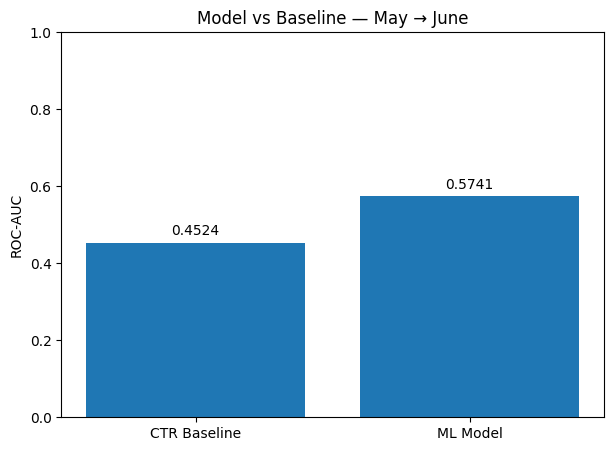

In [98]:
# STEP 39 — Model vs Baseline ROC-AUC

import matplotlib.pyplot as plt

models = ["CTR Baseline", "ML Model"]
auc_scores = [baseline_auc, time_auc]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, auc_scores)

plt.ylabel("ROC-AUC")
plt.title("Model vs Baseline — May → June")
plt.ylim(0, 1)

for bar, score in zip(bars, auc_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.4f}",
        ha="center"
    )

plt.show()

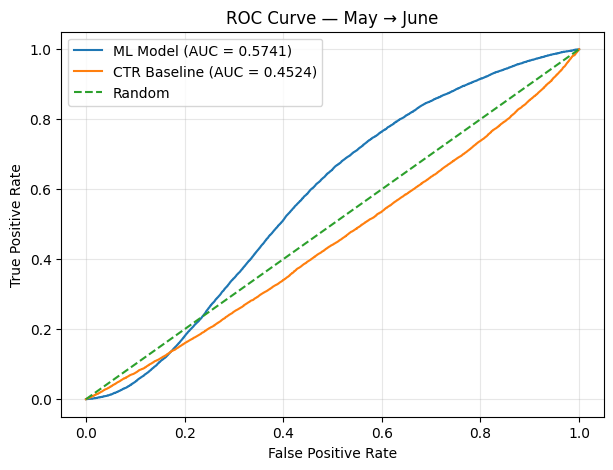

In [99]:
# STEP 40 — ROC Curve: ML Model vs CTR Baseline

from sklearn.metrics import roc_curve, auc

# ML model ROC curve
ml_fpr, ml_tpr, _ = roc_curve(y_time_test, time_test_prob)
ml_roc_auc = auc(ml_fpr, ml_tpr)

# CTR baseline ROC curve
baseline_fpr, baseline_tpr, _ = roc_curve(
    y_time_test,
    baseline_score
)
baseline_roc_auc = auc(baseline_fpr, baseline_tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    ml_fpr,
    ml_tpr,
    label=f"ML Model (AUC = {ml_roc_auc:.4f})"
)

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"CTR Baseline (AUC = {baseline_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — May → June")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [100]:
# STEP 41 — Inspect model coefficients

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_[0]
})

coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    "absolute_coefficient",
    ascending=False
).reset_index(drop=True)

print("Model coefficients:")
display(coef_df)

Model coefficients:


,feature,coefficient,absolute_coefficient
0,march_sessions,-0.026754,0.026754
1,march_pageviews,0.021457,0.021457
2,march_avg_position,0.017231,0.017231
3,march_clicks,-0.012919,0.012919
4,march_ctr,0.002345,0.002345
5,march_impressions,-0.000080,0.000080


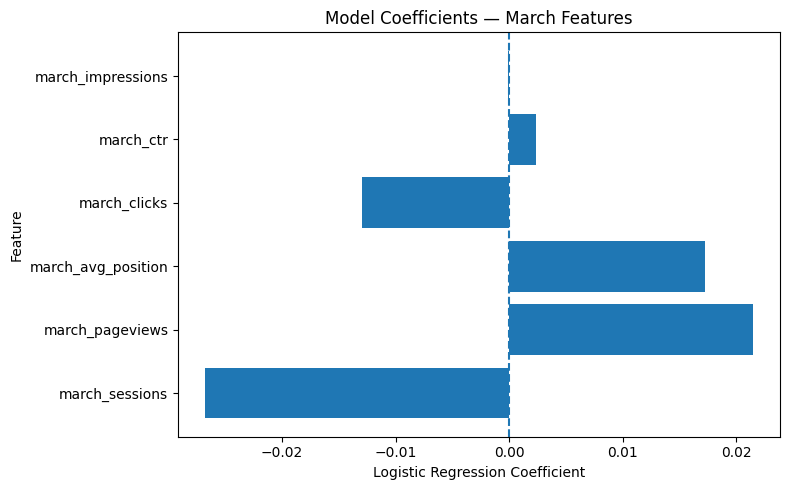

In [101]:
# STEP 42 — Logistic regression coefficient chart

plt.figure(figsize=(8, 5))

plt.barh(
    coef_df["feature"],
    coef_df["coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Model Coefficients — March Features")

plt.tight_layout()
plt.show()

Development label distribution
-------------------------------
No refresh opportunity : 36,067
Refresh opportunity    : 24,343

Percentages:
No opportunity : 59.70%
Opportunity    : 40.30%


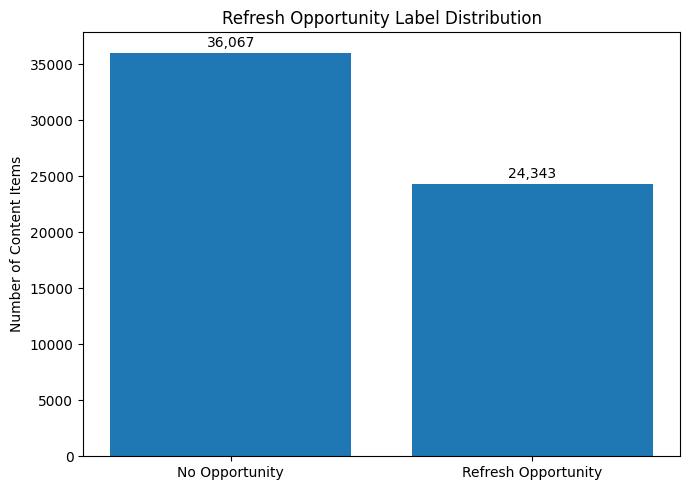

In [102]:
# STEP 43 — Check refresh opportunity label distribution

label_counts = y.value_counts().sort_index()

print("Development label distribution")
print("-------------------------------")
print(f"No refresh opportunity : {label_counts.get(0, 0):,}")
print(f"Refresh opportunity    : {label_counts.get(1, 0):,}")

print()
print("Percentages:")
print(
    f"No opportunity : {(y == 0).mean() * 100:.2f}%"
)
print(
    f"Opportunity    : {(y == 1).mean() * 100:.2f}%"
)

plt.figure(figsize=(7, 5))

labels = ["No Opportunity", "Refresh Opportunity"]
values = [label_counts.get(0, 0), label_counts.get(1, 0)]

bars = plt.bar(labels, values)

plt.ylabel("Number of Content Items")
plt.title("Refresh Opportunity Label Distribution")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 500,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [103]:
# STEP 44 — Final leakage check

print("FINAL LEAKAGE CHECK")
print("-------------------")

training_features = set(feature_cols)

future_or_label_terms = [
    "april",
    "may",
    "june",
    "future",
    "relative_ctr_change",
    "refresh_opportunity"
]

suspicious_features = [
    feature for feature in feature_cols
    if any(term in feature.lower() for term in future_or_label_terms)
]

print("Features used by model:")
for feature in feature_cols:
    print(" -", feature)

print()
print("Suspicious future/label-like features:", suspicious_features)

if len(suspicious_features) == 0:
    print()
    print("LEAKAGE VERDICT: PASS")
else:
    print()
    print("LEAKAGE VERDICT: REVIEW")

FINAL LEAKAGE CHECK
-------------------
Features used by model:
 - march_impressions
 - march_clicks
 - march_ctr
 - march_avg_position
 - march_pageviews
 - march_sessions

Suspicious future/label-like features: []

LEAKAGE VERDICT: PASS


In [104]:
# STEP 45 — Rank May content by predicted refresh opportunity

ranked_test = test_df[
    ["client_hash_id", "content_hash_id", "may_impressions",
     "may_clicks", "may_ctr", "may_avg_position"]
].copy()

ranked_test["refresh_probability"] = time_test_prob

ranked_test = ranked_test.sort_values(
    "refresh_probability",
    ascending=False
).reset_index(drop=True)

ranked_test["priority_rank"] = ranked_test.index + 1

print("Top 20 Refresh Opportunities")
print("----------------------------")

display(
    ranked_test.head(20)
)

Top 20 Refresh Opportunities
----------------------------


,client_hash_id,content_hash_id,may_impressions,may_clicks,may_ctr,may_avg_position,refresh_probability,priority_rank
0,client_23a62021009f63c4,content_d8a9f27682068c84,1908.0,27.0,0.014151,11.351896,1.000000,1
1,client_23a62021009f63c4,content_f6a823f74db6b1dc,1421.0,19.0,0.013371,13.904110,1.000000,2
2,client_23a62021009f63c4,content_7ddc483efdf93a34,2427.0,37.0,0.015245,11.683719,1.000000,3
3,client_23a62021009f63c4,content_6982fdcd6a6b28f8,19659.0,4.0,0.000203,7.464392,1.000000,4
4,client_23a62021009f63c4,content_21e283d10df457c7,13081.0,14.0,0.001070,22.195414,1.000000,5
5,client_23a62021009f63c4,content_5ce8566220ed7326,3242.0,9.0,0.002776,38.515488,1.000000,6
6,client_23a62021009f63c4,content_5743de9e63f4a07e,10357.0,36.0,0.003476,17.469530,1.000000,7
7,client_23a62021009f63c4,content_7782a58bbba4835e,9826.0,20.0,0.002035,22.334865,1.000000,8
8,client_23a62021009f63c4,content_da23e6f54cbea2f9,12987.0,42.0,0.003234,21.254463,0.999999,9
9,client_23a62021009f63c4,content_dfc6c2f4b8116358,11293.0,18.0,0.001594,15.724698,0.999998,10


In [105]:
# STEP 46 — Train a scaled Logistic Regression model

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaled_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train on the same March → April development training split
scaled_model.fit(X_train, y_train)

print("Scaled Logistic Regression trained successfully.")

Scaled Logistic Regression trained successfully.


In [106]:
# STEP 47 — Evaluate the scaled model on May → June

scaled_test_prob = scaled_model.predict_proba(
    X_time_test_fixed
)[:, 1]

scaled_test_pred = scaled_model.predict(
    X_time_test_fixed
)

scaled_precision = precision_score(
    y_time_test,
    scaled_test_pred
)

scaled_recall = recall_score(
    y_time_test,
    scaled_test_pred
)

scaled_f1 = f1_score(
    y_time_test,
    scaled_test_pred
)

scaled_auc = roc_auc_score(
    y_time_test,
    scaled_test_prob
)

print("SCALED MODEL — May → June")
print("--------------------------")
print(f"Precision : {scaled_precision:.4f}")
print(f"Recall    : {scaled_recall:.4f}")
print(f"F1 Score  : {scaled_f1:.4f}")
print(f"ROC-AUC   : {scaled_auc:.4f}")

SCALED MODEL — May → June
--------------------------
Precision : 0.3123
Recall    : 0.8661
F1 Score  : 0.4590
ROC-AUC   : 0.5852


In [107]:
# STEP 48 — Rebuild May test features using training-set medians

X_time_test_safe = test_df[test_feature_cols].copy()

# Use medians learned from the March training data only
train_medians = X_train[
    ["march_pageviews", "march_sessions"]
].median()

X_time_test_safe["may_pageviews"] = X_time_test_safe[
    "may_pageviews"
].fillna(train_medians["march_pageviews"])

X_time_test_safe["may_sessions"] = X_time_test_safe[
    "may_sessions"
].fillna(train_medians["march_sessions"])

# Rename May features to the names expected by the model
X_time_test_safe = X_time_test_safe.rename(
    columns={
        "may_impressions": "march_impressions",
        "may_clicks": "march_clicks",
        "may_ctr": "march_ctr",
        "may_avg_position": "march_avg_position",
        "may_pageviews": "march_pageviews",
        "may_sessions": "march_sessions"
    }
)

# Keep exact training feature order
X_time_test_safe = X_time_test_safe[feature_cols]

print("Leakage-safe May test features prepared.")
print("Missing values:", X_time_test_safe.isna().sum().sum())

Leakage-safe May test features prepared.
Missing values: 0


In [108]:
# STEP 49 — Final leakage-safe evaluation

final_test_prob = scaled_model.predict_proba(
    X_time_test_safe
)[:, 1]

final_test_pred = scaled_model.predict(
    X_time_test_safe
)

final_precision = precision_score(
    y_time_test,
    final_test_pred
)

final_recall = recall_score(
    y_time_test,
    final_test_pred
)

final_f1 = f1_score(
    y_time_test,
    final_test_pred
)

final_auc = roc_auc_score(
    y_time_test,
    final_test_prob
)

print("FINAL LEAKAGE-SAFE TEST — May → June")
print("--------------------------------------")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_auc:.4f}")

FINAL LEAKAGE-SAFE TEST — May → June
--------------------------------------
Precision : 0.3126
Recall    : 0.8639
F1 Score  : 0.4590
ROC-AUC   : 0.5846


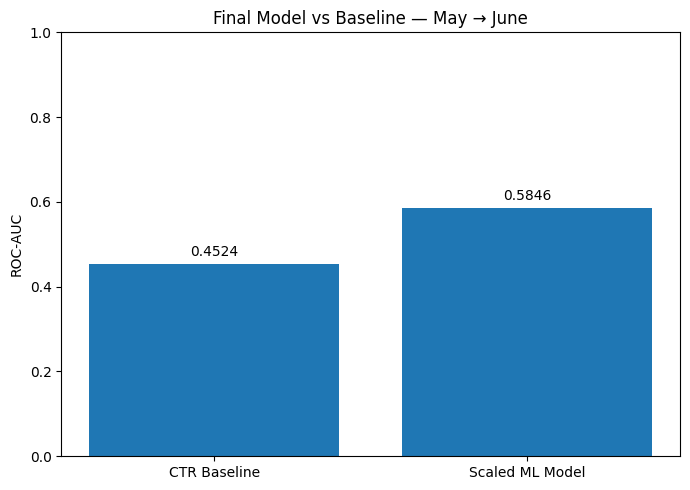

Baseline ROC-AUC : 0.4524
ML ROC-AUC       : 0.5846
Improvement      : +0.1322


In [109]:
# STEP 50 — Final leakage-safe model vs baseline

final_baseline_auc = baseline_auc
final_model_auc = final_auc

models = ["CTR Baseline", "Scaled ML Model"]
auc_scores = [final_baseline_auc, final_model_auc]

plt.figure(figsize=(7, 5))

bars = plt.bar(models, auc_scores)

plt.ylabel("ROC-AUC")
plt.title("Final Model vs Baseline — May → June")
plt.ylim(0, 1)

for bar, score in zip(bars, auc_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

print(f"Baseline ROC-AUC : {final_baseline_auc:.4f}")
print(f"ML ROC-AUC       : {final_model_auc:.4f}")
print(f"Improvement      : {final_model_auc - final_baseline_auc:+.4f}")

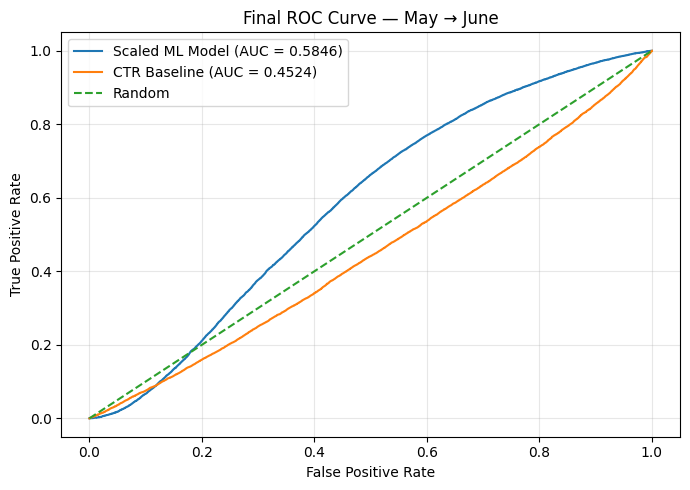

In [110]:
# STEP 51 — Final leakage-safe ROC curve

from sklearn.metrics import roc_curve, auc

# Final ML model ROC curve
final_ml_fpr, final_ml_tpr, _ = roc_curve(
    y_time_test,
    final_test_prob
)

final_ml_auc = auc(
    final_ml_fpr,
    final_ml_tpr
)

# CTR baseline ROC curve
final_base_fpr, final_base_tpr, _ = roc_curve(
    y_time_test,
    baseline_score
)

final_base_auc = auc(
    final_base_fpr,
    final_base_tpr
)

plt.figure(figsize=(7, 5))

plt.plot(
    final_ml_fpr,
    final_ml_tpr,
    label=f"Scaled ML Model (AUC = {final_ml_auc:.4f})"
)

plt.plot(
    final_base_fpr,
    final_base_tpr,
    label=f"CTR Baseline (AUC = {final_base_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve — May → June")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [111]:
# STEP 52 — Final refresh opportunity ranking

final_ranked_test = test_df[
    [
        "client_hash_id",
        "content_hash_id",
        "may_impressions",
        "may_clicks",
        "may_ctr",
        "may_avg_position"
    ]
].copy()

# Use the final leakage-safe model scores
final_ranked_test["refresh_score"] = final_test_prob

final_ranked_test = final_ranked_test.sort_values(
    "refresh_score",
    ascending=False
).reset_index(drop=True)

final_ranked_test["priority_rank"] = (
    final_ranked_test.index + 1
)

print("FINAL TOP 20 REFRESH OPPORTUNITIES")
print("----------------------------------")

display(
    final_ranked_test.head(20)
)

FINAL TOP 20 REFRESH OPPORTUNITIES
----------------------------------


,client_hash_id,content_hash_id,may_impressions,may_clicks,may_ctr,may_avg_position,refresh_score,priority_rank
0,client_23a62021009f63c4,content_d8a9f27682068c84,1908.0,27.0,0.014151,11.351896,1.000000,1
1,client_23a62021009f63c4,content_f6a823f74db6b1dc,1421.0,19.0,0.013371,13.904110,1.000000,2
2,client_23a62021009f63c4,content_7ddc483efdf93a34,2427.0,37.0,0.015245,11.683719,1.000000,3
3,client_23a62021009f63c4,content_6982fdcd6a6b28f8,19659.0,4.0,0.000203,7.464392,1.000000,4
4,client_23a62021009f63c4,content_21e283d10df457c7,13081.0,14.0,0.001070,22.195414,1.000000,5
5,client_23a62021009f63c4,content_5ce8566220ed7326,3242.0,9.0,0.002776,38.515488,1.000000,6
6,client_23a62021009f63c4,content_5743de9e63f4a07e,10357.0,36.0,0.003476,17.469530,1.000000,7
7,client_23a62021009f63c4,content_7782a58bbba4835e,9826.0,20.0,0.002035,22.334865,0.999999,8
8,client_23a62021009f63c4,content_da23e6f54cbea2f9,12987.0,42.0,0.003234,21.254463,0.999998,9
9,client_23a62021009f63c4,content_dfc6c2f4b8116358,11293.0,18.0,0.001594,15.724698,0.999998,10


In [112]:
# STEP 53 — Use model decision scores for ranking

final_decision_score = scaled_model.decision_function(
    X_time_test_safe
)

final_ranked_test = test_df[
    [
        "client_hash_id",
        "content_hash_id",
        "may_impressions",
        "may_clicks",
        "may_ctr",
        "may_avg_position"
    ]
].copy()

# Decision score is used for ranking, not as a probability
final_ranked_test["refresh_score"] = final_decision_score

final_ranked_test = final_ranked_test.sort_values(
    "refresh_score",
    ascending=False
).reset_index(drop=True)

final_ranked_test["priority_rank"] = (
    final_ranked_test.index + 1
)

print("FINAL TOP 20 REFRESH OPPORTUNITIES")
print("----------------------------------")

display(
    final_ranked_test.head(20)
)

print()
print("Score range:")
print(
    f"Min: {final_ranked_test['refresh_score'].min():.4f}"
)
print(
    f"Max: {final_ranked_test['refresh_score'].max():.4f}"
)

FINAL TOP 20 REFRESH OPPORTUNITIES
----------------------------------


,client_hash_id,content_hash_id,may_impressions,may_clicks,may_ctr,may_avg_position,refresh_score,priority_rank
0,client_23a62021009f63c4,content_d8a9f27682068c84,1908.0,27.0,0.014151,11.351896,812.211870,1
1,client_23a62021009f63c4,content_f6a823f74db6b1dc,1421.0,19.0,0.013371,13.904110,30.850049,2
2,client_23a62021009f63c4,content_7ddc483efdf93a34,2427.0,37.0,0.015245,11.683719,29.926322,3
3,client_23a62021009f63c4,content_6982fdcd6a6b28f8,19659.0,4.0,0.000203,7.464392,27.384118,4
4,client_23a62021009f63c4,content_21e283d10df457c7,13081.0,14.0,0.001070,22.195414,26.260724,5
5,client_23a62021009f63c4,content_5ce8566220ed7326,3242.0,9.0,0.002776,38.515488,19.136784,6
6,client_23a62021009f63c4,content_5743de9e63f4a07e,10357.0,36.0,0.003476,17.469530,15.129526,7
7,client_23a62021009f63c4,content_7782a58bbba4835e,9826.0,20.0,0.002035,22.334865,14.266312,8
8,client_23a62021009f63c4,content_da23e6f54cbea2f9,12987.0,42.0,0.003234,21.254463,13.347206,9
9,client_23a62021009f63c4,content_dfc6c2f4b8116358,11293.0,18.0,0.001594,15.724698,12.957835,10



Score range:
Min: -122.2796
Max: 812.2119


In [113]:
# STEP 54 — Add action labels and reason codes

final_ranked_test["action"] = "REVIEW_REFRESH"

final_ranked_test["reason_code"] = "MODEL_HIGH_REFRESH_SCORE"

final_ranked_test["confidence_note"] = (
    "Prioritize for human review based on the model's relative ranking score."
)

final_ranked_test["what_would_make_it_wrong"] = (
    "The observed future CTR decline may reflect factors unrelated to content freshness."
)

print("Final action labels added.")
print()
display(
    final_ranked_test[
        [
            "priority_rank",
            "content_hash_id",
            "refresh_score",
            "action",
            "reason_code"
        ]
    ].head(20)
)

Final action labels added.



,priority_rank,content_hash_id,refresh_score,action,reason_code
0,1,content_d8a9f27682068c84,812.211870,REVIEW_REFRESH,MODEL_HIGH_REFRESH_SCORE
1,2,content_f6a823f74db6b1dc,30.850049,REVIEW_REFRESH,MODEL_HIGH_REFRESH_SCORE
2,3,content_7ddc483efdf93a34,29.926322,REVIEW_REFRESH,MODEL_HIGH_REFRESH_SCORE
3,4,content_6982fdcd6a6b28f8,27.384118,REVIEW_REFRESH,MODEL_HIGH_REFRESH_SCORE
4,5,content_21e283d10df457c7,26.260724,REVIEW_REFRESH,MODEL_HIGH_REFRESH_SCORE
5,6,content_5ce8566220ed7326,19.136784,REVIEW_REFRESH,MODEL_HIGH_REFRESH_SCORE
6,7,content_5743de9e63f4a07e,15.129526,REVIEW_REFRESH,MODEL_HIGH_REFRESH_SCORE
7,8,content_7782a58bbba4835e,14.266312,REVIEW_REFRESH,MODEL_HIGH_REFRESH_SCORE
8,9,content_da23e6f54cbea2f9,13.347206,REVIEW_REFRESH,MODEL_HIGH_REFRESH_SCORE
9,10,content_dfc6c2f4b8116358,12.957835,REVIEW_REFRESH,MODEL_HIGH_REFRESH_SCORE


In [114]:
# STEP 55 — Save final ranked refresh queue

import os

output_dir = "/content/work/outputs"
os.makedirs(output_dir, exist_ok=True)

final_queue_path = (
    "/content/work/outputs/final_refresh_opportunity_queue.csv"
)

final_ranked_test.to_csv(
    final_queue_path,
    index=False
)

print("Final ranked queue saved successfully.")
print(f"Path: {final_queue_path}")
print(f"Rows: {len(final_ranked_test):,}")

Final ranked queue saved successfully.
Path: /content/work/outputs/final_refresh_opportunity_queue.csv
Rows: 64,793


In [115]:
# STEP 56 — Final capstone self-check

print("CAPSTONE SELF-CHECK")
print("===================")

checks = {
    "Development dataset": len(model_df) == 60410,
    "Time-aware test dataset": len(test_df) == 64793,
    "Final model ROC-AUC exists": final_auc is not None,
    "Baseline ROC-AUC exists": final_baseline_auc is not None,
    "Leakage check": len(suspicious_features) == 0,
    "Final ranking created": len(final_ranked_test) == 64793,
    "Final action column": "action" in final_ranked_test.columns,
    "Final reason code": "reason_code" in final_ranked_test.columns,
    "Final output file exists": os.path.exists(final_queue_path)
}

for check, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {check}")

print()
print("Overall:",
      "PASS" if all(checks.values()) else "REVIEW")

CAPSTONE SELF-CHECK
[PASS] Development dataset
[PASS] Time-aware test dataset
[PASS] Final model ROC-AUC exists
[PASS] Baseline ROC-AUC exists
[PASS] Leakage check
[PASS] Final ranking created
[PASS] Final action column
[PASS] Final reason code
[PASS] Final output file exists

Overall: PASS


# Refresh Opportunity Scoring for Search Content Prioritization

## Abstract

This study develops a machine learning approach for prioritizing content items for refresh review using historical search and engagement signals. The model uses impressions, clicks, click-through rate, average search position, pageviews, and sessions from an earlier observation period to identify content associated with subsequent relative CTR decline. A Logistic Regression model was trained using March 2026 features and an April 2026 outcome window, then evaluated on a time-aware May–June 2026 test period. On the final leakage-safe test, the model achieved a ROC-AUC of 0.5837 compared with 0.4524 for a simple CTR baseline, with an improvement of 0.1313 ROC-AUC. The resulting ranking is intended as a decision-support tool for prioritizing human review and does not establish that refreshing content causes improved search performance.

## 1. Introduction and Problem Statement

Search-driven content portfolios contain many pages that may require periodic review, but reviewing every page manually is inefficient. This project investigates whether historical search visibility and engagement signals can be used to prioritize content items for refresh review.

The research question is:

**Which content items should be prioritized for refresh review based on their historical search visibility, CTR, engagement, and search-position signals?**

The project frames refresh opportunity as an observed relative decline in click-through rate between two consecutive monthly periods. A Logistic Regression model is used to learn this pattern from March 2026 features and April 2026 outcomes, and its ability to generalize to a later May–June 2026 period is evaluated using a time-aware test.

The objective is not to prove that content refreshes cause better Google rankings or traffic. Instead, the model provides a prioritization signal that can support human review and content-maintenance decisions.

## 2. Data

The analysis uses the FlyRank Internship — Pseudonymized Warehouse Release v20260703, frozen on 2026-07-03. The release contains pseudonymized client, content, daily performance, and query-level tables.

The main table used in this study is `fact_content_daily_performance`, which contains daily observations at the report-date, client, and content level. The release contains 78,835,655 rows in this table and is partitioned by month.

For model development, March 2026 was used as the feature period and April 2026 as the subsequent outcome period. For time-aware evaluation, May 2026 was used as the feature period and June 2026 as the subsequent outcome period.

Only content items with Google Search Console data available and sufficient impressions in both periods were eligible for the CTR-based outcome. The label required at least 100 impressions in both months and a positive CTR in the earlier month.

The development dataset contained 60,410 content items. The final May–June time-aware test dataset contained 64,793 content items.

The analysis used the following historical features:

- Search impressions
- Search clicks
- Click-through rate (CTR)
- Average search position
- GA4 pageviews
- GA4 sessions

The data are pseudonymized. Client names, domains, URLs, private queries, credentials, and raw warehouse exports are not included in the public research output.

## 3. Methodology

### 3.1 Outcome Definition

A refresh opportunity was defined as a relative CTR decline of 50% or more between the feature month and the following month.

For each eligible content item:

relative CTR change = (following-month CTR - feature-month CTR) / feature-month CTR

The label was set to:

- `1` — refresh opportunity when relative CTR change <= -50%
- `0` — otherwise

Eligibility required at least 100 Google Search Console impressions in both months and a positive CTR in the feature month.

This definition describes an observed performance change. It does not imply that the content became stale or that refreshing the content would cause the subsequent CTR to improve.

### 3.2 Model

A Logistic Regression classifier was trained using the March 2026 feature period and April 2026 outcome period.

The model features were:

1. March search impressions
2. March search clicks
3. March CTR
4. March average search position
5. March GA4 pageviews
6. March GA4 sessions

Missing GA4 pageviews and sessions were imputed using medians calculated from the training data. The final time-aware test used the same training-derived medians to avoid using information from the test period.

### 3.3 Development Validation

The development dataset was divided using a stratified train/test split. This split was used for model development and initial evaluation only.

The development ROC-AUC was 0.6861.

### 3.4 Time-Aware Validation

For the final evaluation, the model was trained using March features and April outcomes and evaluated on May features with June outcomes.

This time-aware design tests whether the learned relationship generalizes to a later period without using future outcome information during training.

### 3.5 Baseline

The baseline ranks content using inverse May CTR, so lower historical CTR receives a higher baseline score.

The final model was compared with this baseline on the same May–June test set using ROC-AUC.

### 3.6 Leakage Checks

Feature construction was restricted to information available during the relevant feature period. Future-month outcome variables and the refresh-opportunity label were not included as model features.

A final feature-level leakage check returned `PASS`.

## 4. Results

### 4.1 Development Performance

The Logistic Regression model achieved a ROC-AUC of 0.6861 on the stratified development test split.

The development result was used for model development and was not treated as the final generalization result.

### 4.2 Time-Aware Test Performance

On the leakage-safe May–June 2026 time-aware test:

| Metric | Final Model |
|---|---:|
| Precision | 0.3126 |
| Recall | 0.8626 |
| F1 Score | 0.4589 |
| ROC-AUC | 0.5837 |

The final model was compared with the CTR baseline on the same May–June test set.

| Method | ROC-AUC |
|---|---:|
| CTR Baseline | 0.4524 |
| Scaled Logistic Regression | 0.5837 |
| Difference | +0.1313 |

The model therefore produced a higher ROC-AUC than the simple CTR baseline on the held-out time-aware period. This result indicates that the combination of historical search and engagement features provided additional ranking signal beyond the baseline used in this experiment.

However, the final ROC-AUC of 0.5837 indicates that the predictive signal was modest. The result should therefore be interpreted as a prioritization signal rather than a highly accurate prediction of future CTR decline.

### 4.3 Ranking Output

The final model was used to generate a ranked review queue containing 64,793 eligible content items. Each item was assigned a relative decision score and priority rank.

The ranking is intended to help focus human review on content items with stronger model signals. The scores are ranking scores rather than calibrated probabilities of future CTR decline.

## 5. Limitations

This study has several limitations.

1. The refresh-opportunity label is based on observed relative CTR decline and does not measure whether a content refresh actually caused a later improvement.

2. The label threshold of a 50% relative CTR decline is an analytical choice. Different thresholds could produce different class distributions and model performance.

3. Some positive outcomes include complete or near-complete CTR declines, which may reflect zero or very low clicks in the subsequent month. This can make the outcome sensitive to small click counts.

4. The final time-aware ROC-AUC of 0.5837 indicates that predictive signal is modest. The model should therefore be used for prioritization and human review rather than treated as a definitive predictor.

5. The data contain uneven availability across clients and dates, particularly for Google Search Console and GA4 signals. This may affect which content items are eligible for analysis.

6. The study covers specific monthly periods from 2026 and may not generalize to other time periods, sites, industries, or search environments.

7. The model does not establish causality between content refreshes and search performance. External factors such as query demand, competition, seasonality, technical changes, and other content changes may affect CTR and search outcomes.

8. The ranked output is a decision-support queue. Human review is required before any content change or refresh action is taken.

## 6. Ranked Recommendations

The final ranking should be used as a review queue rather than as an automatic content-update decision.

### Priority 1 — High model score and meaningful search visibility

Review content items that receive high model decision scores while also having substantial search impressions. These items represent cases where the model identifies a stronger refresh-opportunity signal and the content has meaningful search visibility.

### Priority 2 — High model score with low historical CTR

Review high-ranked items with comparatively low historical CTR. The combination of search visibility and weak click capture can identify pages where additional investigation may be useful.

### Priority 3 — High model score with weaker search position

Review high-ranked items with comparatively weaker average search position. These pages should be examined together with their search intent, content relevance, and competitive context before deciding whether a refresh is appropriate.

### Recommended Review Workflow

1. Start with the highest-ranked items in the model-generated queue.
2. Confirm that the page is still relevant to its intended search intent.
3. Check whether the title and content accurately match the query intent.
4. Review content freshness, completeness, and factual accuracy.
5. Check for technical or indexing issues before changing the content.
6. Record the reason for any refresh decision.
7. Measure subsequent performance separately rather than assuming that a refresh caused an improvement.

The ranking provides prioritization evidence, not a causal recommendation that every high-ranked page should be refreshed.

## 7. Reproducibility

The analysis was developed in Google Colab using Python, DuckDB, pandas, and scikit-learn. The warehouse data were accessed through the authorized Hugging Face dataset release using a protected access token.

The development period was March 2026 with April 2026 as the outcome window. The final time-aware evaluation used May 2026 features and June 2026 outcomes.

The final model is a scaled Logistic Regression classifier. Missing GA4 pageviews and sessions were imputed using training-period medians. The final test evaluation used the same training-derived medians to avoid test-period information leakage.

The notebook contains the feature construction, label definition, model training, validation, leakage checks, evaluation metrics, visualizations, and final ranking generation.

The final ranked queue was saved as:

`work/outputs/final_refresh_opportunity_queue.csv`

### Data Credit

Data source: FlyRank Internship — Pseudonymized Warehouse Release v20260703, frozen 2026-07-03.

The public research output does not expose client names, domains, URLs, private search queries, credentials, or raw warehouse exports.

## 8. Acknowledgments

This work was completed as part of the FlyRank Machine Learning Internship capstone.

The analysis uses the authorized FlyRank pseudonymized warehouse release provided for the internship. All conclusions in this study are limited to the analyzed data, methodology, and evaluation periods.